## 🧠 Sleep Blindspots — Signal Exploration

### Objective

Load and visualize raw EEG signals alongside sleep stage annotations from the Sleep-EDF dataset.

The goal of this notebook is to **understand the structure of the data** before building any machine learning models.

---

### What We Are Looking For

We want to observe how:

- EEG signals behave across different sleep stages  
- Sleep stages evolve over time  
- Transitions between stages appear in the signal  

---

### Key Idea

Sleep stages are labeled as discrete categories: W, N1, N2, N3, REM


However, the underlying physiological signals are continuous.

This raises an important question:

> **Do all sleep stage transitions correspond to clear changes in the EEG signal?**

---

### Approach

1. Load PSG (EEG) signal from EDF file  
2. Load hypnogram (sleep stage annotations)  
3. Extract a single EEG channel (Fpz-Cz)  
4. Align signal with sleep stage labels  
5. Visualize EEG and sleep stages over time  

---

### Expected Outcome

By the end of this notebook, we should:

- Understand the temporal structure of the recording  
- Identify stable vs transition regions in sleep  
- Recognize that some stage changes are ambiguous in the signal  

---

### Note

The full recording includes long periods of wakefulness before and after sleep.

We will focus on identifying the **meaningful sleep region** for further analysis.


In [27]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE = Path("../data/raw/physionet.org/files/sleep-edfx/1.0.0/sleep-cassette")

psg_file = BASE / "SC4001E0-PSG.edf"
hyp_file = BASE / "SC4001EC-Hypnogram.edf"

In [3]:
raw = mne.io.read_raw_edf(psg_file, preload=True)

print(raw.info)

Extracting EDF parameters from ../data/raw/physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


/var/folders/53/ps9kkpj52j71m9fx4fmfqxsw0000gn/T/ipykernel_52819/3807008273.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/var/folders/53/ps9kkpj52j71m9fx4fmfqxsw0000gn/T/ipykernel_52819/3807008273.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/var/folders/53/ps9kkpj52j71m9fx4fmfqxsw0000gn/T/ipykernel_52819/3807008273.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_file, preload=True)


Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>


In [4]:
raw.pick_channels(["EEG Fpz-Cz"])

data, times = raw.get_data(return_times=True)

data = data[0]  # single channel

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


In [20]:
annot = mne.read_annotations(hyp_file)

# Align annotation time with signal time
annot.onset = annot.onset - annot.onset[0]

raw.set_annotations(annot)

/var/folders/53/ps9kkpj52j71m9fx4fmfqxsw0000gn/T/ipykernel_52819/1973562247.py:6: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


<RawEDF | SC4001E0-PSG.edf, 1 x 7950000 (79500.0 s), ~60.7 MiB, data loaded>

In [21]:
events, event_dict = mne.events_from_annotations(raw)

print(event_dict)

Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage ?'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
{np.str_('Sleep stage 1'): 1, np.str_('Sleep stage 2'): 2, np.str_('Sleep stage 3'): 3, np.str_('Sleep stage 4'): 4, np.str_('Sleep stage ?'): 5, np.str_('Sleep stage R'): 6, np.str_('Sleep stage W'): 7}


In [22]:
label_map = {
    "Sleep stage W": 0,   # Wake
    "Sleep stage 1": 1,   # N1
    "Sleep stage 2": 2,   # N2
    "Sleep stage 3": 3,   # N3
    "Sleep stage 4": 3,   # merge old stage 4 into N3
    "Sleep stage R": 4,   # REM
}

In [23]:
sfreq = raw.info["sfreq"]

labels = np.full(len(times), -1)

for onset, duration, description in zip(annot.onset, annot.duration, annot.description):
    description = str(description)

    if description in label_map:
        start = int(onset * sfreq)
        end = int((onset + duration) * sfreq)
        labels[start:end] = label_map[description]

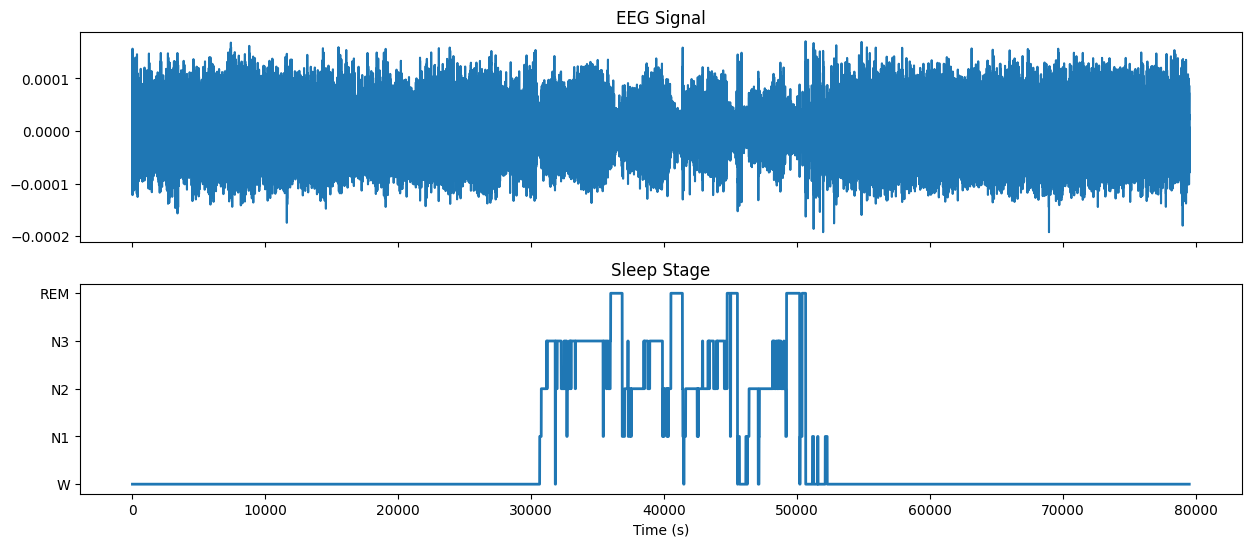

In [25]:
# ===== FULL RANGE =====
end_idx = len(times)
# =====================

plot_labels = labels.astype(float)
plot_labels[plot_labels == -1] = np.nan

fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axs[0].plot(times[:end_idx], data[:end_idx])
axs[0].set_title("EEG Signal")

axs[1].plot(times[:end_idx], plot_labels[:end_idx], linewidth=2)
axs[1].set_title("Sleep Stage")
axs[1].set_yticks([0,1,2,3,4])
axs[1].set_yticklabels(["W","N1","N2","N3","REM"])

plt.xlabel("Time (s)")
plt.show()

In [26]:
print("Sampling freq:", raw.info["sfreq"])
print("Total samples:", len(times))
print("Total duration (sec):", times[-1])
print("Total duration (hours):", times[-1] / 3600)

Sampling freq: 100.0
Total samples: 7950000
Total duration (sec): 79499.99
Total duration (hours): 22.083330555555555


In [28]:
start_time = 30000   # pick a region with transitions
end_time   = 32000   # ~20 minutes window

mask = (times >= start_time) & (times <= end_time)

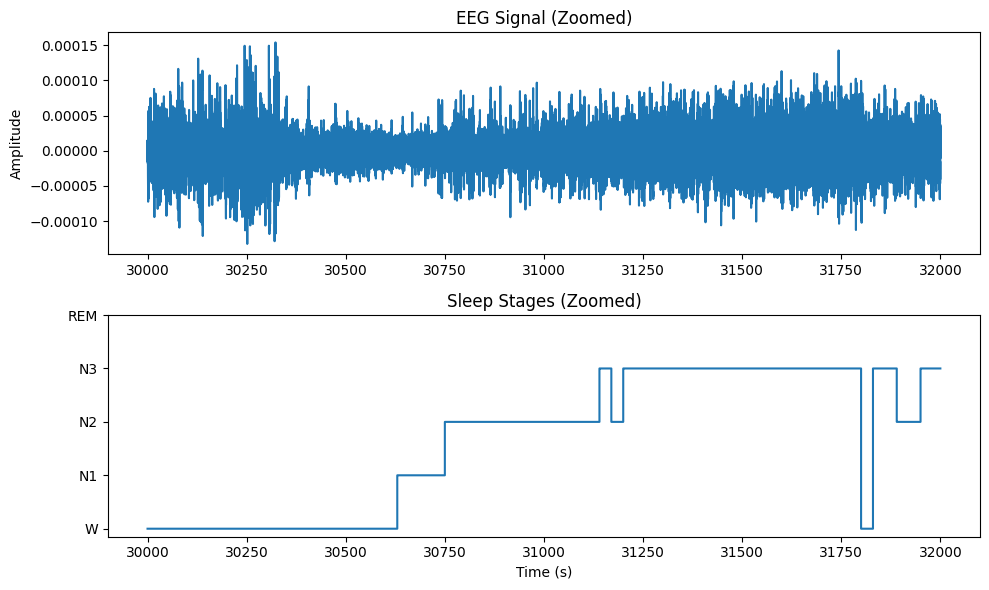

In [29]:
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(times[mask], data[mask])
plt.title("EEG Signal (Zoomed)")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.step(times[mask], plot_labels[mask], where="post")
plt.yticks([0,1,2,3,4], ["W","N1","N2","N3","REM"])
plt.title("Sleep Stages (Zoomed)")
plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()